# NSPPK ZINC Streaming Benchmark

This notebook demonstrates the new two-stage source-ingestion workflow:

1. load a small subset of remote ZINC molecules as `networkx` graphs with `load_from(...)`
2. fit an `NSPPK` vectorizer on that subset
3. stream transformed batches from the full remote source with `stream_from(...)`

The structural statistics below are computed on the warmup subset. The timing section measures batched transformation over the selected remote stream.

## Configure the benchmark

This cell imports the required libraries, chooses the source URI, and sets the benchmark parameters. The key controls are the warmup subset size, the streamed fraction or count, the batch size used by `stream_from(...)`, and the NSPPK hyperparameters used for featurization.

In [7]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from nsppk import NSPPK

ZINC_URL = 'https://cache.docking.org/2D/AA/AAAE.smi'
HIV_DATA_PATH = 'data/HIV.csv'

TEST_TYPE = 'URL' # 'URL' or 'FILE'
if TEST_TYPE == 'URL':
    URI = ZINC_URL
elif TEST_TYPE == 'FILE':
    URI = HIV_DATA_PATH

WARMUP_LIMIT = 1000
STREAM_LIMIT = 0.05
RANDOM_STATE = 42
BATCH_SIZE = 256

RADIUS = 1
DISTANCE = 4
CONNECTOR = 1
NBITS = 15


## Load a warmup subset as graphs

Use `load_from(...)` to materialize a reproducible subset of remote SMILES as `networkx` graphs. This subset is used for structural inspection and vectorizer fitting.

In [8]:
vectorizer = NSPPK(
    radius=RADIUS,
    distance=DISTANCE,
    connector=CONNECTOR,
    nbits=NBITS,
    dense=False,
    parallel=False,
)

warmup_graphs = vectorizer.load_from(
    URI,
    'smiles',
    limit=WARMUP_LIMIT,
    random_state=RANDOM_STATE,
    verbose=True,
)

len(warmup_graphs)

[load_from] progress: seen=      1  loaded=      1  errors=    0  elapsed=    3.49s  graphs/sec=    0.29  sec/graph=  3.490195
[load_from] progress: seen=    100  loaded=    100  errors=    0  elapsed=    3.53s  graphs/sec=   28.30  sec/graph=  0.035333
[load_from] progress: seen=    200  loaded=    200  errors=    0  elapsed=    3.65s  graphs/sec=   54.85  sec/graph=  0.018232
[load_from] progress: seen=    300  loaded=    300  errors=    0  elapsed=    3.69s  graphs/sec=   81.23  sec/graph=  0.012311
[load_from] progress: seen=    400  loaded=    400  errors=    0  elapsed=    3.74s  graphs/sec=  107.00  sec/graph=  0.009346
[load_from] progress: seen=    500  loaded=    500  errors=    0  elapsed=    3.78s  graphs/sec=  132.26  sec/graph=  0.007561
[load_from] progress: seen=    600  loaded=    600  errors=    0  elapsed=    3.82s  graphs/sec=  157.07  sec/graph=  0.006367
[load_from] progress: seen=    700  loaded=    700  errors=    0  elapsed=    3.86s  graphs/sec=  181.23  sec/g

1000

## Build a tabular summary of the warmup graphs

The next cell converts the loaded `networkx` graphs into a DataFrame of per-graph statistics, then aggregates those values into a compact summary table. This provides a quick view of graph size, connectivity, density, and label diversity before any vectorization happens.

In [9]:
warmup_stats_df = pd.DataFrame(
    {
        'smiles': [graph.graph.get('smiles') for graph in warmup_graphs],
        'n_nodes': [graph.number_of_nodes() for graph in warmup_graphs],
        'n_edges': [graph.number_of_edges() for graph in warmup_graphs],
        'density': [nx.density(graph) if graph.number_of_nodes() > 1 else 0.0 for graph in warmup_graphs],
        'n_components': [nx.number_connected_components(graph) for graph in warmup_graphs],
        'is_connected': [nx.is_connected(graph) if graph.number_of_nodes() > 0 else False for graph in warmup_graphs],
        'n_unique_node_labels': [len({graph.nodes[node]['label'] for node in graph.nodes()}) for graph in warmup_graphs],
        'n_unique_edge_labels': [len({graph.edges[u, v]['label'] for u, v in graph.edges()}) for graph in warmup_graphs],
    }
)

summary_df = warmup_stats_df[['n_nodes', 'n_edges', 'density', 'n_components', 'n_unique_node_labels', 'n_unique_edge_labels']].describe().T
summary_df['connected_fraction'] = np.nan
summary_df.loc['n_components', 'connected_fraction'] = warmup_stats_df['is_connected'].mean()

display(warmup_stats_df.head())
summary_df

,smiles,n_nodes,n_edges,density,n_components,is_connected,n_unique_node_labels,n_unique_edge_labels
0,OCCC[C@@H](O)[C@@H](O)CO,10,9,0.200000,1,True,3,1
1,NC[C@H]1CC(=O)NO1,8,8,0.285714,1,True,7,4
2,C[C@H](O)[C@H](O)[C@H](O)[C@H](O)[C@H](O)CO,13,12,0.153846,1,True,4,1
3,O=C1C[C@H](O)[C@H]([C@H](O)CO)O1,11,11,0.200000,1,True,5,4
4,N[C@H](C(=O)O)C(=O)C(=O)O,10,9,0.200000,1,True,5,3


,count,mean,std,min,25%,50%,75%,max,connected_fraction
n_nodes,1000.0,12.371000,1.317230,6.000000,12.000000,13.000000,13.000000,14.0,NaN
n_edges,1000.0,12.501000,1.697315,6.000000,12.000000,13.000000,14.000000,16.0,NaN
density,1000.0,0.179771,0.023848,0.153846,0.164835,0.179487,0.181818,0.4,NaN
n_components,1000.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
n_unique_node_labels,1000.0,7.774000,1.501059,3.000000,7.000000,8.000000,9.000000,13.0,NaN
n_unique_edge_labels,1000.0,3.529000,1.091031,1.000000,3.000000,4.000000,4.000000,7.0,NaN


## Plot graph-size distributions

This plotting cell visualizes how large the warmup graphs are. The histograms use integer-width bins and integer ticks so each bar corresponds exactly to one node count or edge count.

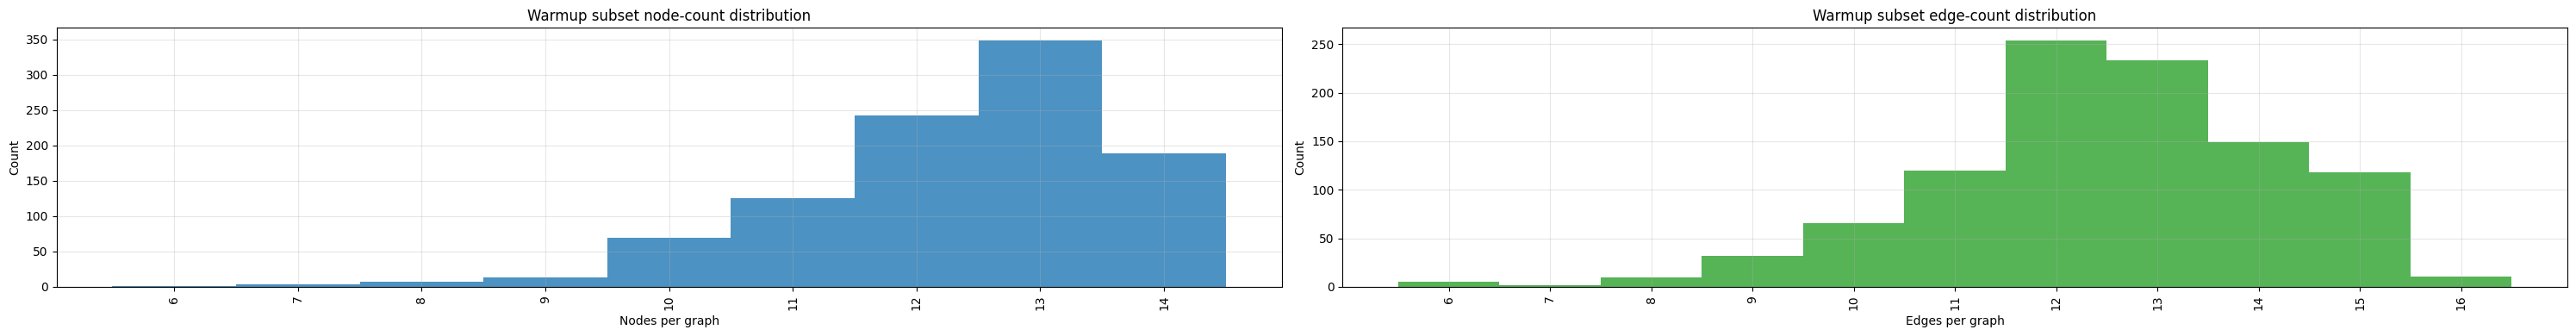

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(30, 4))

node_min = int(warmup_stats_df['n_nodes'].min())
node_max = int(warmup_stats_df['n_nodes'].max())
node_bins = np.arange(node_min - 0.5, node_max + 1.5, 1)
edge_min = int(warmup_stats_df['n_edges'].min())
edge_max = int(warmup_stats_df['n_edges'].max())
edge_bins = np.arange(edge_min - 0.5, edge_max + 1.5, 1)

axes[0].hist(warmup_stats_df['n_nodes'], bins=node_bins, color='tab:blue', alpha=0.8)
axes[0].set_title('Warmup subset node-count distribution')
axes[0].set_xlabel('Nodes per graph')
axes[0].set_ylabel('Count')
axes[0].set_xticks(np.arange(node_min, node_max + 1, 1))
axes[0].tick_params(axis='x', labelrotation=90)
axes[0].grid(True, alpha=0.3)

axes[1].hist(warmup_stats_df['n_edges'], bins=edge_bins, color='tab:green', alpha=0.8)
axes[1].set_title('Warmup subset edge-count distribution')
axes[1].set_xlabel('Edges per graph')
axes[1].set_ylabel('Count')
axes[1].set_xticks(np.arange(edge_min, edge_max + 1, 1))
axes[1].tick_params(axis='x', labelrotation=90)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Fit on the warmup subset and stream transformed batches

The timing below measures end-to-end batch transformation from the remote source using `stream_from(...)`. Set `STREAM_LIMIT` to an integer or a probability in `(0, 1)` to benchmark only part of the source.

### Fit the vectorizer on the warmup subset

Before streaming transformed batches, the encoder must be fitted. This fit step uses only the warmup subset, which matches the intended workflow when the full source is too large to keep in memory.

In [11]:
%%time 
vectorizer.fit(warmup_graphs)

CPU times: user 80 μs, sys: 1 μs, total: 81 μs
Wall time: 89.6 μs


,radius,1
,distance,4
,connector,1
,nbits,15
,degree_threshold,None
,dense,False
,parallel,False
,weight_key,None
,node_attribute_key,None
,edge_attribute_key,None
,attribute_dim,None


### Stream transformed batches and measure throughput

This final benchmark cell calls `stream_from(...)`, which loads graphs lazily from the source, transforms them in batches, and yields feature matrices. The code tracks how many rows were produced, how many batches were emitted, and the overall throughput of the full streaming pass.

In [12]:
batch_rows = []
batch_times = []
n_batches = 0
total_rows = 0

t0 = time.perf_counter()
for X_batch in vectorizer.stream_from(
    URI,
    'smiles',
    limit=STREAM_LIMIT,
    batch_size=BATCH_SIZE,
    verbose=True,
):
    batch_start = time.perf_counter()
    n_rows = X_batch.shape[0]
    batch_rows.append(n_rows)
    total_rows += n_rows
    n_batches += 1
    batch_times.append(time.perf_counter() - batch_start)
elapsed_sec = time.perf_counter() - t0

timing_summary = pd.Series(
    {
        'graphs_streamed': total_rows,
        'batches': n_batches,
        'elapsed_sec': elapsed_sec,
        'graphs_per_sec': total_rows / elapsed_sec if elapsed_sec else np.nan,
        'ms_per_graph': 1000.0 * elapsed_sec / total_rows if total_rows else np.nan,
        'mean_batch_rows': float(np.mean(batch_rows)) if batch_rows else np.nan,
        'max_batch_rows': int(np.max(batch_rows)) if batch_rows else np.nan,
    }
)

timing_summary

[stream_from] progress: seen=      1  loaded=      1  errors=    0  elapsed=    3.68s  graphs/sec=    0.27  sec/graph=  3.679622
[stream_from] progress: seen=    100  loaded=    100  errors=    0  elapsed=    4.71s  graphs/sec=   21.23  sec/graph=  0.047107
[stream_from] progress: seen=    200  loaded=    200  errors=    0  elapsed=    5.61s  graphs/sec=   35.64  sec/graph=  0.028058
[stream_from] progress: seen=    300  loaded=    300  errors=    0  elapsed=   13.44s  graphs/sec=   22.33  sec/graph=  0.044784
[stream_from] progress: seen=    400  loaded=    400  errors=    0  elapsed=   14.17s  graphs/sec=   28.23  sec/graph=  0.035426
[stream_from] progress: seen=    500  loaded=    500  errors=    0  elapsed=   14.98s  graphs/sec=   33.38  sec/graph=  0.029960
[stream_from] progress: seen=    600  loaded=    600  errors=    0  elapsed=   22.92s  graphs/sec=   26.18  sec/graph=  0.038200
[stream_from] progress: seen=    700  loaded=    700  errors=    0  elapsed=   23.75s  graphs/sec

graphs_streamed    10582.000000
batches               42.000000
elapsed_sec          388.596938
graphs_per_sec        27.231300
ms_per_graph          36.722447
mean_batch_rows      251.952381
max_batch_rows       256.000000
dtype: float64